In [2]:
%pip install -qU chromadb openai pypdf2 python-docx python-multipart sentence-transformers huggingface_hub pycryptodome accelerate pymupdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Het Parikh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import docx
import PyPDF2
import os


def read_text_file(file_path: str):
    """Read content from a text file"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()

def read_pdf_file(file_path: str):
    """Read content from a PDF file"""
    text = ""
    with open(file_path, 'rb') as file:
        pdf_reader = PyPDF2.PdfReader(file)
        for page in pdf_reader.pages:
            text += page.extract_text() + "\n"
    return text

def read_docx_file(file_path: str):
    """Read content from a Word document"""
    doc = docx.Document(file_path)
    return "\n".join([paragraph.text for paragraph in doc.paragraphs])



In [5]:
def read_document(file_path: str):
    """Read document content based on file extension"""
    _, file_extension = os.path.splitext(file_path)
    file_extension = file_extension.lower()

    if file_extension == '.txt':
        return read_text_file(file_path)
    elif file_extension == '.pdf':
        return read_pdf_file(file_path)
    elif file_extension == '.docx':
        return read_docx_file(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_extension}")
text = read_document("C:\\Users\\Het Parikh\\OneDrive\\Desktop\\Advanced Multi-Source RAG\\Docs\\GreenGrow's EcoHarvest System_ A Revolution in Farming.pdf")
print(text)


GreenGrow
Innovations'
EcoHarvest
System
has
been
hailed
as
a
game-changer
in
the
agricultural
industry
since
its
introduction
in
2018.
This
integrated
system
combines
several
technologies
to
optimize
crop
growth,
reduce
resource
consumption,
and
automate
harvesting
processes.
At
the
heart
of
the
EcoHarvest
System
is
the
central
AI-powered
control
unit.
This
unit
processes
data
from
various
sensors
placed
throughout
the
farm,
including
soil
moisture
sensors,
weather
stations,
and
crop
growth
monitors.
By
analyzing
this
data
in
real-time,
the
system
can
make
informed
decisions
about
irrigation,
fertilization,
and
pest
control.
One
of
the
key
components
of
the
EcoHarvest
System
is
its
smart
irrigation
module.
This
module
uses
a
network
of
precision
sprinklers
and
drip
irrigation
systems
that
can
be
individually
controlled.
By
delivering
water
exactly
where
and
when
it's
needed,
the
system
has
been
shown
to
reduce
water
usage
by
up
to
40%
compared
to
traditional
irrigation
methods.
The
so

# **Text Chunking Strategy**
Once we have the raw text, we need to split it into manageable chunks. This is crucial for two reasons:

1.   More precise semantic search results

2.   Staying within LLM context windows


---

In [10]:
def split_text(text: str, chunk_size: int = 1500):
    """Split text into chunks while preserving sentence boundaries"""
    sentences = text.replace('\n', ' ').split('. ')
    chunks = []
    current_chunk = []
    current_size = 0

    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue

        # Ensure proper sentence ending
        if not sentence.endswith('.'):
            sentence += '.'

        sentence_size = len(sentence)

        # Check if adding this sentence would exceed chunk size
        if current_size + sentence_size > chunk_size and current_chunk:
            chunks.append(' '.join(current_chunk))
            current_chunk = [sentence]
            current_size = sentence_size
        else:
            current_chunk.append(sentence)
            current_size += sentence_size

    # Add the last chunk if it exists
    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks
chunks = split_text(text)





In [11]:
len(chunks)

2

# **Setting Up ChromaDB**
---



In [14]:
import chromadb
from chromadb.utils import embedding_functions

# Initialize ChromaDB client with persistence
chroma_client = chromadb.PersistentClient(path="C:\\Users\\Het Parikh\\OneDrive\\Desktop\\Advanced Multi-Source RAG\\chroma_db")

# Configure sentence transformer embeddings
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

# Create or get existing collection
collection = chroma_client.get_or_create_collection(
    name="documents_collection",
    embedding_function=sentence_transformer_ef
)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

# **Inserting Data into ChromaDB**

---


In [ ]:
def process_document(file_path: str):
    """Process a single document and prepare it for ChromaDB"""
    try:
        # Read the document
        content = read_document(file_path)

        # Split into chunks
        chunks = split_text(content)

        # Prepare metadata
        file_name = os.path.basename(file_path)
        metadatas = [{"source": file_name, "chunk": i} for i in range(len(chunks))]
        ids = [f"{file_name}_chunk_{i}" for i in range(len(chunks))]

        return ids, chunks, metadatas
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return [], [], []

def add_to_collection(collection, ids, texts, metadatas):
    """Add documents to collection in batches"""
    if not texts:
        return

    batch_size = 100
    for i in range(0, len(texts), batch_size):
        end_idx = min(i + batch_size, len(texts))
        collection.add(
            documents=texts[i:end_idx],
            metadatas=metadatas[i:end_idx],
            ids=ids[i:end_idx]
        )

def process_and_add_documents(collection, folder_path: str):
    """Process all documents in a folder and add to collection"""
    files = [os.path.join(folder_path, file)
             for file in os.listdir(folder_path)
             if os.path.isfile(os.path.join(folder_path, file))]

    for file_path in files:
        print(f"Processing {os.path.basename(file_path)}...")
        ids, texts, metadatas = process_document(file_path)
        add_to_collection(collection, ids, texts, metadatas)
        print(f"Added {len(texts)} chunks to collection")


In [ ]:
process_and_add_documents(collection, "C:\\Users\\Het Parikh\\OneDrive\\Desktop\\Advanced Multi-Source RAG\\Docs\\")

Processing Smarten-Working-with-Key-Influencers.pdf...
Added 19 chunks to collection
Processing Smarten-V5-Feature-List.pdf...
Added 12 chunks to collection
Processing Smarten-Comprehensive-Guide-for-Effective-Visualizations.pdf...
Added 78 chunks to collection
Processing Smarten-Concept-Manual-SSDP.pdf...
Added 224 chunks to collection
Processing Smarten-Working-with-GeoMaps.pdf...
Added 53 chunks to collection
Processing Smarten-Guidelines-for-Network-Performance-Testing.pdf...
Added 42 chunks to collection
Processing Smarten-Working-with-Audit-Logs.pdf...
Added 20 chunks to collection
Processing Smarten-High-Availability-Architecture.pdf...
Added 11 chunks to collection
Processing Smarten-Concept-Manual-SnapShot.pdf...
Added 57 chunks to collection
Processing Smarten-Responsive-Design-Concept.pdf...
Added 41 chunks to collection
Processing Smarten-Load-Balancing-Clustering-Architecture.pdf...
Added 17 chunks to collection
Processing Smarten-Performance-Data-Sheet.pdf...
Added 8 chun

# **Implementing Semantic Search**

---



In [ ]:
def semantic_search(collection, query: str, n_results: int = 2):
    """Perform semantic search on the collection"""
    results = collection.query(
        query_texts=[query],
        n_results=n_results
    )
    return results

def get_context_with_sources(results):
    """Extract context and source information from search results"""
    # Combine document chunks into a single context
    context = "\n\n".join(results['documents'][0])

    # Format sources with metadata
    sources = [
        f"{meta['source']} (chunk {meta['chunk']})"
        for meta in results['metadatas'][0]
    ]

    return context, sources

In [ ]:
query = "What is a PMML file?"
results = semantic_search(collection, query)
results

{'ids': [['Smarten-PMML-FAQs.pdf_chunk_7', 'Smarten-PMML-FAQs.pdf_chunk_9']],
 'embeddings': None,
 'documents': [['8                                             1 What is a PMML file?   PMML stands for “Predictive Model Markup Language.” It is an XML -based model interchange  format designed to provide a way through which predictive solutions can be transferred from one  application to another.',
   'It supports  other aspects, such as data dictionary, data transformations, and missing value treatment, and that  makes PMML as an “all in one”  format that supports in teroperability of models among different  tools and applications without a need for custom coding. PMML also supports transparency; thus, models are no more a “black box.” Anyone can actually  readthe PMML model by simply opening the PMML file!   3 How do you create a PMML file?  A PMML file contains a pretrained model.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[

In [ ]:
def print_search_results(results):
    """Print formatted search results"""
    print("\nSearch Results:\n" + "-" * 50)

    for i in range(len(results['documents'][0])):
        doc = results['documents'][0][i]
        meta = results['metadatas'][0][i]
        distance = results['distances'][0][i]

        print(f"\nResult {i + 1}")
        print(f"Source: {meta['source']}, Chunk {meta['chunk']}")
        print(f"Distance: {distance}")
        print(f"Content: {doc}\n")

print_search_results(results)


Search Results:
--------------------------------------------------

Result 1
Source: Smarten-PMML-FAQs.pdf, Chunk 7
Distance: 0.14997464418411255
Content: 8                                             1 What is a PMML file?   PMML stands for “Predictive Model Markup Language.” It is an XML -based model interchange  format designed to provide a way through which predictive solutions can be transferred from one  application to another.


Result 2
Source: Smarten-PMML-FAQs.pdf, Chunk 9
Distance: 0.23271536827087402
Content: It supports  other aspects, such as data dictionary, data transformations, and missing value treatment, and that  makes PMML as an “all in one”  format that supports in teroperability of models among different  tools and applications without a need for custom coding. PMML also supports transparency; thus, models are no more a “black box.” Anyone can actually  readthe PMML model by simply opening the PMML file!   3 How do you create a PMML file?  A PMML file contains a

# **HuggingFace Integration**
Now that we have our document retrieval system in place, let's integrate llama's API to create the generation part of our RAG system. We'll focus on crafting effective prompts and managing the conversation flow.

---



In [ ]:
import os
os.environ['HF_TOKEN'] = ''

In [ ]:
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "user",
            "content": "What is Retrieval-Argumented Generation(RAG) in simple words"
        }
    ],
)

print(completion.choices[0].message)

ChatCompletionMessage(content="Retrieval-Augmented Generation (RAG) is a deep learning technique used for language generation tasks such as answering questions, writing articles, or generating text. It combines two stages: retrieval and generation.\n\n**Stage 1: Retrieval**\nIn this stage, a model is trained to find relevant information from a large dataset or knowledge base. It identifies the most relevant text passages, paragraphs, or sentences that match the input query or topic. Think of this as searching for the most related information online.\n\n**Stage 2: Generation**\nOnce the relevant information is retrieved, the model generates a well-structured response based on that information. This response is crafted to be coherent, accurate, and engaging.\n\nThe key benefit of RAG is that it leverages the strengths of both retrieval and generation models. The retrieval stage can access vast amounts of information, while the generation stage can create a well-structured and coherent re

In [ ]:
print(completion.choices[0].message.content)

Retrieval-Augmented Generation (RAG) is a deep learning technique used for language generation tasks such as answering questions, writing articles, or generating text. It combines two stages: retrieval and generation.

**Stage 1: Retrieval**
In this stage, a model is trained to find relevant information from a large dataset or knowledge base. It identifies the most relevant text passages, paragraphs, or sentences that match the input query or topic. Think of this as searching for the most related information online.

**Stage 2: Generation**
Once the relevant information is retrieved, the model generates a well-structured response based on that information. This response is crafted to be coherent, accurate, and engaging.

The key benefit of RAG is that it leverages the strengths of both retrieval and generation models. The retrieval stage can access vast amounts of information, while the generation stage can create a well-structured and coherent response. This makes RAG particularly eff

In [ ]:
def get_prompt(context: str, conversation_history: str, query: str):
    """Generate a prompt combining context, history, and query"""
    prompt = f"""Based on the following context and conversation history,
    please provide a relevant and contextual response. If the answer cannot
    be derived from the context, only use the conversation history or say
    "I cannot answer this based on the provided information."

    Context from documents:
    {context}

    Previous conversation:
    {conversation_history}

    Human: {query}

    Assistant:"""

    return prompt


def generate_response(query: str, context: str, conversation_history: str = ""):
    """Generate a response using Llama with conversation history"""
    prompt = get_prompt(context, conversation_history, query)

    try:
        response = client.chat.completions.create(
            model="meta-llama/Llama-3.1-8B-Instruct",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that answers questions based on the provided context."},
                {"role": "user", "content": prompt}
            ],
            temperature=0,  # Lower temperature for more focused responses
            max_tokens=500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error generating response: {str(e)}"


In [ ]:
def rag_query(collection, query: str, n_chunks: int = 2):
    """Perform RAG query: retrieve relevant chunks and generate answer"""
    # Get relevant chunks
    results = semantic_search(collection, query, n_chunks)
    context, sources = get_context_with_sources(results)

    # Generate response
    response = generate_response(query, context)

    return response, sources


In [ ]:
query = "What is a PMML file?"
response, sources = rag_query(collection, query)

# Print results
print("\nQuery:", query)
print("\nAnswer:", response)
print("\nSources used:")
for source in sources:
    print(f"- {source}")



Query: What is a PMML file?

Answer: PMML stands for “Predictive Model Markup Language.” It is an XML-based model interchange format designed to provide a way through which predictive solutions can be transferred from one application to another.

Sources used:
- Smarten-PMML-FAQs.pdf (chunk 7)
- Smarten-PMML-FAQs.pdf (chunk 9)


# **Coversational RAG**

In [ ]:
import uuid
from datetime import datetime
import json

# In-memory conversation store
conversations = {}

def create_session():
    """Create a new conversation session"""
    session_id = str(uuid.uuid4())
    conversations[session_id] = []
    return session_id

def add_message(session_id: str, role: str, content: str):
    """Add a message to the conversation history"""
    if session_id not in conversations:
        conversations[session_id] = []

    conversations[session_id].append({
        "role": role,
        "content": content,
        "timestamp": datetime.now().isoformat()
    })

def get_conversation_history(session_id: str, max_messages: int = None):
    """Get conversation history for a session"""
    if session_id not in conversations:
        return []

    history = conversations[session_id]
    if max_messages:
        history = history[-max_messages:]

    return history


In [ ]:
def format_history_for_prompt(session_id: str, max_messages: int = 5):
    """Format conversation history for inclusion in prompts"""
    history = get_conversation_history(session_id, max_messages)
    formatted_history = ""

    for msg in history:
        role = "Human" if msg["role"] == "user" else "Assistant"
        formatted_history += f"{role}: {msg['content']}\n\n"

    return formatted_history.strip()


# **Query Contextualization**

In [ ]:
def contextualize_query(query: str, conversation_history: str, client: OpenAI):
    """Convert follow-up questions into standalone queries"""
    contextualize_prompt = """Given a chat history and the latest user question
    which might reference context in the chat history, formulate a standalone
    question which can be understood without the chat history. Do NOT answer
    the question, just reformulate it if needed and otherwise return it as is."""

    try:
        completion = client.chat.completions.create(
            model="meta-llama/Llama-3.1-8B-Instruct",
            messages=[
                {"role": "system", "content": contextualize_prompt},
                {"role": "user", "content": f"Chat history:\n{conversation_history}\n\nQuestion:\n{query}"}
            ]
        )
        return completion.choices[0].message.content
    except Exception as e:
        print(f"Error contextualizing query: {str(e)}")
        return query  # Fallback to original query


In [ ]:
def get_prompt(context, conversation_history, query):
  prompt = f"""Based on the following context and conversation history, please provide a relevant and contextual response.
    If the answer cannot be derived from the context, only use the conversation history or say "I cannot answer this based on the provided information."

    Context from documents:
    {context}

    Previous conversation:
    {conversation_history}

    Human: {query}

    Assistant:"""
  return prompt


In [ ]:
def generate_response(query: str, context: str, conversation_history: str = ""):
    """Generate a response using OpenAI with conversation history"""
    prompt = get_prompt(context, conversation_history, query)
    # print(prompt)

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {"role": "system", "content": prompt}
        ],
        temperature=0,
        max_tokens=500
    )

    return response.choices[0].message.content

# **Final Conversational RAG**

In [ ]:
def conversational_rag_query(
    collection,
    query: str,
    session_id: str,
    n_chunks: int = 3
):
    """Perform RAG query with conversation history"""
    # Get conversation history
    conversation_history = format_history_for_prompt(session_id)

    # Handle follo up questions
    query = contextualize_query(query, conversation_history, client)
    print("Contextualized Query:", query)

    # Get relevant chunks
    context, sources = get_context_with_sources(
        semantic_search(collection, query, n_chunks)
    )
    print("Context:", context)
    print("Sources:", sources)


    response = generate_response(query, context, conversation_history)

    # Add to conversation history
    add_message(session_id, "user", query)
    add_message(session_id, "assistant", response)

    return response, sources


In [ ]:
# Create a new conversation session
session_id = create_session()

# First question
query = "What is the PMML file?"
response, sources = conversational_rag_query(
            collection,
            query,
            session_id
)
print(response)


Contextualized Query: The question "What is the PMML file?" does not explicitly reference any context from the chat history. If we assume that there is no information about PMML that has been previously mentioned in the chat history, the question is already understood in its current form. Therefore, the standalone question remains as is: 

"What is the PMML file?"
Context: 8                                             1 What is a PMML file?   PMML stands for “Predictive Model Markup Language.” It is an XML -based model interchange  format designed to provide a way through which predictive solutions can be transferred from one  application to another.

It supports  other aspects, such as data dictionary, data transformations, and missing value treatment, and that  makes PMML as an “all in one”  format that supports in teroperability of models among different  tools and applications without a need for custom coding. PMML also supports transparency; thus, models are no more a “black box.”

In [ ]:
query = "What are the benefits"
response, sources = conversational_rag_query(
            collection,
            query,
            session_id
)
print(response)


Contextualized Query: Given the question "What are the benefits" and the chat history discussing PMML files, we reformulate it to provide clarity for understanding it without the chat history.

The standalone question remains: 

"What are the benefits of PMML files?"
Context: 8                                             1 What is a PMML file?   PMML stands for “Predictive Model Markup Language.” It is an XML -based model interchange  format designed to provide a way through which predictive solutions can be transferred from one  application to another.

It supports  other aspects, such as data dictionary, data transformations, and missing value treatment, and that  makes PMML as an “all in one”  format that supports in teroperability of models among different  tools and applications without a need for custom coding. PMML also supports transparency; thus, models are no more a “black box.” Anyone can actually  readthe PMML model by simply opening the PMML file!   3 How do you create a P

# **PDF Image Extraction**

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [ ]:
def generate_image_caption(image_path: str):
    image = Image.open(image_path).convert("RGB")
    inputs = blip_processor(image, return_tensors="pt").to(device)

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_length=50)

    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption


In [ ]:
  def caption_image_results(image_results, max_images=2):
    captions = []

    if not image_results["metadatas"]:
        return "No relevant images found in the document."

    for i in range(min(max_images, len(image_results["metadatas"][0]))):
        meta = image_results["metadatas"][0][i]

        caption = generate_image_caption(meta["image_path"])

        captions.append(
            f"- PDF image from {meta['source']} (page {meta['page']}): {caption}"
        )

    return "\n".join(captions)


In [ ]:
image_collection = chroma_client.get_or_create_collection(
    name="image_collection"
)

In [ ]:
def get_image_aware_prompt(
    text_context: str,
    image_captions: str,
    conversation_history: str,
    query: str
):
    prompt = f"""
You are a helpful assistant.

IMPORTANT RULES:
- DO NOT include external image links or URLs.
- DO NOT mention images that are not explicitly described below.
- ONLY use the provided image descriptions.
- If diagrams are referenced, explain them in words.

Text context from documents:
{text_context}

Image descriptions extracted from the PDF:
{image_captions}

Conversation history:
{conversation_history}

Human: {query}

Assistant:
"""
    return prompt


In [ ]:
def generate_image_aware_response(
    query: str,
    text_context: str,
    image_results,
    conversation_history: str = ""
):
    image_captions = caption_image_results(image_results)

    prompt = get_image_aware_prompt(
        text_context=text_context,
        image_captions=image_captions,
        conversation_history=conversation_history,
        query=query
    )

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {"role": "system", "content": prompt}
        ],
        temperature=0,
        max_tokens=500
    )

    return response.choices[0].message.content


In [ ]:
def image_aware_hybrid_rag(
    text_collection,
    image_collection,
    query: str,
    conversation_history: str = ""
):
    retrieval = hybrid_retrieval(
        text_collection,
        image_collection,
        query
    )

    answer = generate_image_aware_response(
        query=query,
        text_context=retrieval["text_context"],
        image_results=retrieval["image_results"],
        conversation_history=conversation_history
    )

    return {
        "answer": answer,
        "text_sources": retrieval["text_sources"],
        "image_results": retrieval["image_results"]
    }


In [ ]:
def hybrid_retrieval(text_collection, image_collection, query, n_text_results=3, n_image_results=0):
    """
    Performs hybrid retrieval, currently only for text as a full image retrieval pipeline
    (extraction, embedding, searching) is not yet implemented in the notebook.
    """
    # Text retrieval
    text_results = semantic_search(text_collection, query, n_text_results)
    text_context, text_sources = get_context_with_sources(text_results)

    # Image retrieval (placeholder for now)
    # In a full implementation, you would search image_collection for relevant images
    # and potentially filter/rank based on relevance.
    image_results = {
        "ids": [[]],
        "embeddings": None,
        "documents": [[]],
        "uris": None,
        "included": ['metadatas', 'documents', 'distances'],
        "data": None,
        "metadatas": [[]],
        "distances": [[]]
    }

    return {
        "text_context": text_context,
        "text_sources": text_sources,
        "image_results": image_results
    }

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image_search_results(image_results):
    """
    Prints a message about image results. In a full implementation, this would display images.
    """
    if not image_results['metadatas'][0]:
        print("No image results to display (image retrieval pipeline not fully implemented or no relevant images found).")
    else:
        # Placeholder for actual image display
        print("Found image results (display functionality not fully implemented):")
        for i, meta in enumerate(image_results['metadatas'][0]):
            print(f"- Image from {meta.get('source', 'unknown')} (page {meta.get('page', 'unknown')}): {meta.get('image_path', 'unknown')}")
            # If actual images were available and saved to disk, you would display them here.
            # Example:
            # try:
            #     img = mpimg.imread(meta['image_path'])
            #     plt.imshow(img)
            #     plt.title(f"Source: {meta['source']}, Page: {meta['page']}")
            #     plt.axis('off')
            #     plt.show()
            # except Exception as e:
            #     print(f"Could not display image {meta['image_path']}: {e}")

In [ ]:
query = "Explain smarten architecture system with daigram"

results = image_aware_hybrid_rag(
    collection,
    image_collection,
    query
)

print("\n🧠 Answer:\n")
print(results["answer"])

print("\n📄 Sources:")
for s in results["text_sources"]:
    print("-", s)

print("\n🖼️ Images retrieved from the PDF:\n")
show_image_search_results(results["image_results"])


🧠 Answer:

Based on the provided information, I'll explain the Smarten architecture system without referencing any external diagrams. 

The Smarten architecture system is a high-level framework designed for corporate performance management and Advanced Data Discovery with enterprise-wide implementation. It consists of several key components:

1. **Managed Memory Computing**: This is a concept that enables efficient memory management, allowing for faster data processing and analysis. It's a crucial component of the Smarten architecture, as it enables the system to handle large amounts of data quickly and efficiently.

2. **Data Ingestion**: This component is responsible for collecting and processing data from various sources, such as databases, files, and other data systems. The data is then stored in a centralized repository for further analysis.

3. **Data Storage**: The data is stored in a centralized repository, which can be a relational database, a NoSQL database, or a data wareho

# **Image Semantic Search**

In [ ]:
!pip install -q torch torchvision ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

def get_text_embedding_for_image_search(text: str):
    text_input = clip.tokenize([text]).to(device)

    with torch.no_grad():
        embedding = clip_model.encode_text(text_input)

    return embedding.cpu().numpy()[0]

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 282MiB/s]


In [ ]:
def get_image_embedding(image_path: str):
    image = Image.open(image_path).convert("RGB")
    image_input = clip_preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = clip_model.encode_image(image_input)

    return embedding.cpu().numpy()[0]


In [ ]:
image_collection = chroma_client.get_or_create_collection(
    name="image_collection"
)

In [ ]:
def add_images_to_collection(image_collection, images, pdf_name):
    embeddings = []
    metadatas = []
    ids = []

    for idx, img in enumerate(images):
        embeddings.append(get_image_embedding(img["path"]))
        metadatas.append({
            "source": pdf_name,
            "page": img["page"],
            "image_path": img["path"]
        })
        ids.append(f"{pdf_name}_img_{idx}")

    image_collection.add(
        embeddings=embeddings,
        metadatas=metadatas,
        ids=ids
    )


In [ ]:
import fitz # Import PyMuPDF
import os

def extract_images_from_pdf(pdf_path: str, output_folder="temp_images"):
    """Extracts images from a PDF and saves them to a temporary folder."""
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    doc = fitz.open(pdf_path)
    images_data = []
    pdf_name = os.path.basename(pdf_path)

    for page_num in range(len(doc)):
        page = doc[page_num]
        image_list = page.get_images(full=True)

        for img_index, img in enumerate(image_list):
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            image_ext = base_image["ext"]
            image_filename = f"{pdf_name}_page{page_num + 1}_img{img_index}.{image_ext}"
            image_path = os.path.join(output_folder, image_filename)

            with open(image_path, "wb") as f:
                f.write(image_bytes)

            images_data.append({
                "path": image_path,
                "page": page_num + 1,
                "source": pdf_name
            })
    doc.close()
    return images_data

pdf_doc_path = "/content/Docs/Smarten-Impact-of-Cube-Design-on-Performance.pdf"

pdf_images = extract_images_from_pdf(pdf_doc_path)

add_images_to_collection(
    image_collection,
    pdf_images,
    "Smarten-Impact-of-Cube-Design-on-Performance.pdf"
)

In [ ]:
def semantic_image_search(image_collection, query: str, n_results=3):
    query_embedding = get_text_embedding_for_image_search(query)

    results = image_collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results
    )

    return results


In [ ]:
import matplotlib.pyplot as plt

def show_image_search_results(results):
    for i in range(len(results["metadatas"][0])):
        meta = results["metadatas"][0][i]
        img = Image.open(meta["image_path"])

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"{meta['source']} | Page {meta['page']}"
        )
        plt.show()


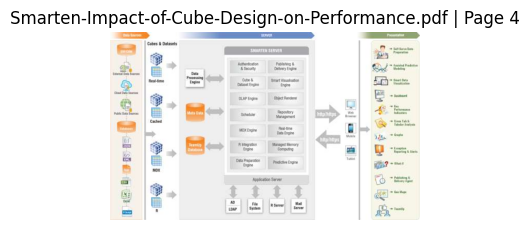

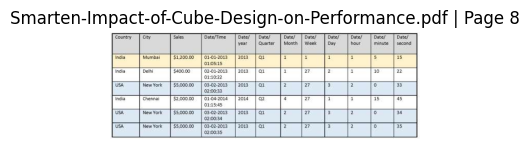

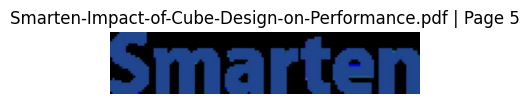

In [ ]:
query = "smarten architecture diagram"

image_results = semantic_image_search(
    image_collection,
    query
)

show_image_search_results(image_results)
